<a href="https://colab.research.google.com/github/Monika9671/heart_disease_prediction/blob/main/Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===============================
# Heart Disease Prediction Project
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# ML
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

print("All libraries loaded")

All libraries loaded


In [2]:
df = pd.read_csv("HeartDiseaseTrain-Test.csv")

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

df.head()

Rows : 1025
Columns : 14


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [3]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            1025 non-null   int64  
 1   sex                            1025 non-null   object 
 2   chest_pain_type                1025 non-null   object 
 3   resting_blood_pressure         1025 non-null   int64  
 4   cholestoral                    1025 non-null   int64  
 5   fasting_blood_sugar            1025 non-null   object 
 6   rest_ecg                       1025 non-null   object 
 7   Max_heart_rate                 1025 non-null   int64  
 8   exercise_induced_angina        1025 non-null   object 
 9   oldpeak                        1025 non-null   float64
 10  slope                          1025 non-null   object 
 11  vessels_colored_by_flourosopy  1025 non-null   object 
 12  thalassemia                    1025 non-null   o

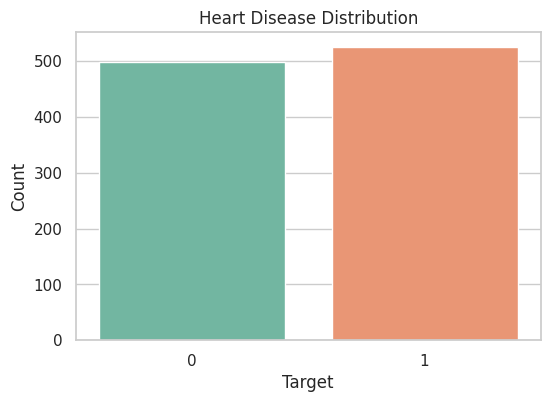

target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6,4))

sns.countplot(x="target", data=df, palette="Set2")

plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

print(df.target.value_counts(normalize=True)*100)

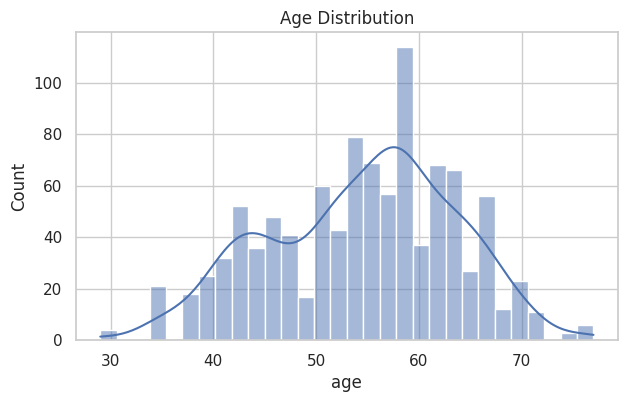

In [5]:
plt.figure(figsize=(7,4))

sns.histplot(df.age, bins=30, kde=True)

plt.title("Age Distribution")

plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

# Create ML dataframe
df_ml = df.copy()

# Encode every text column
le = LabelEncoder()

for col in df_ml.select_dtypes(include="object").columns:
    df_ml[col] = le.fit_transform(df_ml[col])

print(df_ml.dtypes)

age                                int64
sex                                int64
chest_pain_type                    int64
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar                int64
rest_ecg                           int64
Max_heart_rate                     int64
exercise_induced_angina            int64
oldpeak                          float64
slope                              int64
vessels_colored_by_flourosopy      int64
thalassemia                        int64
target                             int64
dtype: object


In [8]:
# ==============================
# Encode categorical columns
# ==============================

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

encoder = LabelEncoder()

# Automatically convert all object columns to numbers
for col in df_encoded.select_dtypes(include="object").columns:
    df_encoded[col] = encoder.fit_transform(df_encoded[col])

print("Categorical columns encoded successfully!")
df_encoded.head()

Categorical columns encoded successfully!


,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,1,3,125,212,1,2,168,0,1.0,0,3,3,0
1,53,1,3,140,203,0,1,155,1,3.1,2,4,3,0
2,70,1,3,145,174,1,2,125,1,2.6,2,4,3,0
3,61,1,3,148,203,1,2,161,0,0.0,0,1,3,0
4,62,0,3,138,294,0,2,106,0,1.9,1,2,0,0


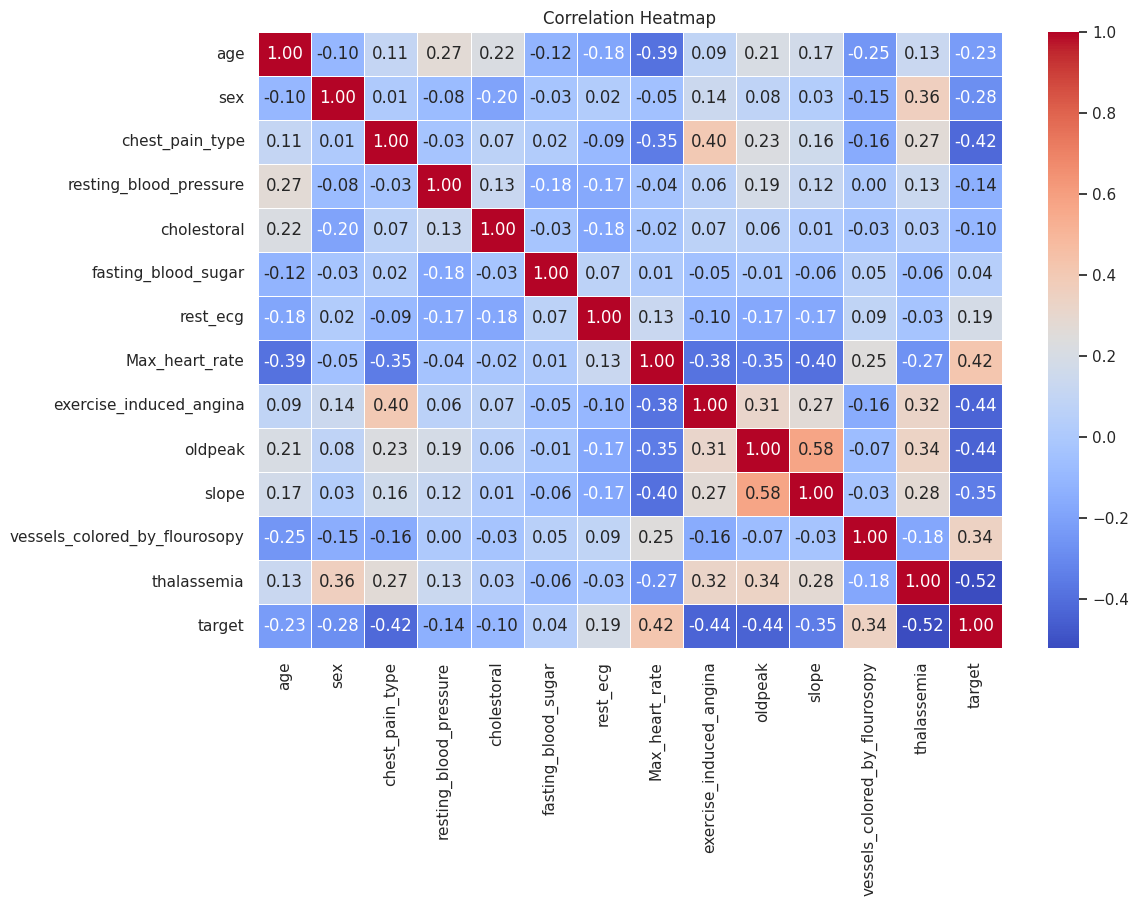

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [11]:
print(df.columns.tolist())

['age', 'sex', 'chest_pain_type', 'resting_blood_pressure', 'cholestoral', 'fasting_blood_sugar', 'rest_ecg', 'Max_heart_rate', 'exercise_induced_angina', 'oldpeak', 'slope', 'vessels_colored_by_flourosopy', 'thalassemia', 'target']


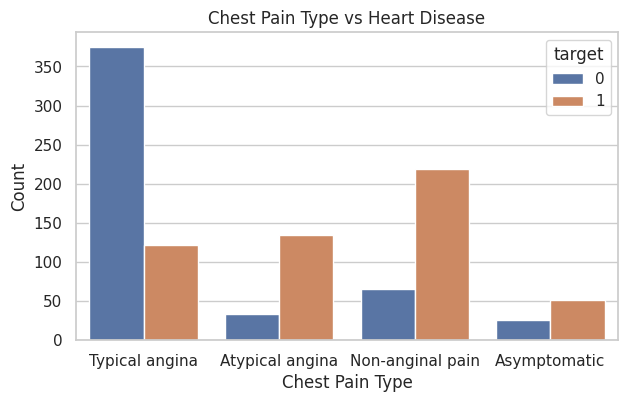

In [12]:
plt.figure(figsize=(7,4))

sns.countplot(
    x="chest_pain_type",
    hue="target",
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.show()

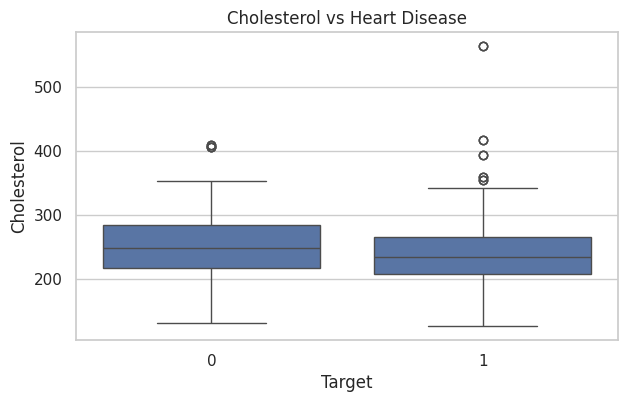

In [15]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x="target",
    y="cholestoral",   # Correct column name
    data=df
)

plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Target")
plt.ylabel("Cholesterol")

plt.show()

In [19]:
for col in df.columns:
    print(col)

age
sex
chest_pain_type
resting_blood_pressure
cholestoral
fasting_blood_sugar
rest_ecg
Max_heart_rate
exercise_induced_angina
oldpeak
slope
vessels_colored_by_flourosopy
thalassemia
target


In [27]:
X = df_ml.drop("target", axis=1)
y = df_ml["target"]

print(X.dtypes)

age                                int64
sex                                int64
chest_pain_type                    int64
resting_blood_pressure             int64
cholestoral                        int64
fasting_blood_sugar                int64
rest_ecg                           int64
Max_heart_rate                     int64
exercise_induced_angina            int64
oldpeak                          float64
slope                              int64
vessels_colored_by_flourosopy      int64
thalassemia                        int64
dtype: object


In [28]:
print(X.shape)

(1025, 13)


In [31]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(820, 13)
(205, 13)


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")

Scaling completed successfully!


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [35]:
svm = SVC(
    probability=True,
    kernel="rbf"
)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [36]:
rf = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [37]:
xgb = XGBClassifier(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=4,

    eval_metric="logloss",

    random_state=42

)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [38]:
def evaluate(model_name, y_true, pred, prob):

    print("="*50)

    print(model_name)

    print("="*50)

    print("Accuracy :", accuracy_score(y_true,pred))

    print("Precision :", precision_score(y_true,pred))

    print("Recall :", recall_score(y_true,pred))

    print("F1 Score :", f1_score(y_true,pred))

    print("ROC AUC :", roc_auc_score(y_true,prob))

    print("\nClassification Report\n")

    print(classification_report(y_true,pred))

In [39]:
evaluate(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr.predict_proba(X_test_scaled)[:,1]
)

evaluate(
    "SVM",
    y_test,
    svm_pred,
    svm.predict_proba(X_test_scaled)[:,1]
)

evaluate(
    "Random Forest",
    y_test,
    rf_pred,
    rf.predict_proba(X_test)[:,1]
)

evaluate(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb.predict_proba(X_test)[:,1]
)

Logistic Regression
Accuracy : 0.8439024390243902
Precision : 0.8230088495575221
Recall : 0.8857142857142857
F1 Score : 0.8532110091743119
ROC AUC : 0.932

Classification Report

              precision    recall  f1-score   support

           0       0.87      0.80      0.83       100
           1       0.82      0.89      0.85       105

    accuracy                           0.84       205
   macro avg       0.85      0.84      0.84       205
weighted avg       0.85      0.84      0.84       205

SVM
Accuracy : 0.9512195121951219
Precision : 0.9523809523809523
Recall : 0.9523809523809523
F1 Score : 0.9523809523809523
ROC AUC : 0.9791428571428572

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       100
           1       0.95      0.95      0.95       105

    accuracy                           0.95       205
   macro avg       0.95      0.95      0.95       205
weighted avg       0.95      0.95      0.95   

In [40]:
results = pd.DataFrame({

    "Model":[

        "Logistic",

        "SVM",

        "Random Forest",

        "XGBoost"

    ],

    "Accuracy":[

        accuracy_score(y_test,lr_pred),

        accuracy_score(y_test,svm_pred),

        accuracy_score(y_test,rf_pred),

        accuracy_score(y_test,xgb_pred)

    ]

})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
3,XGBoost,1.000000
2,Random Forest,1.000000
1,SVM,0.951220
0,Logistic,0.843902


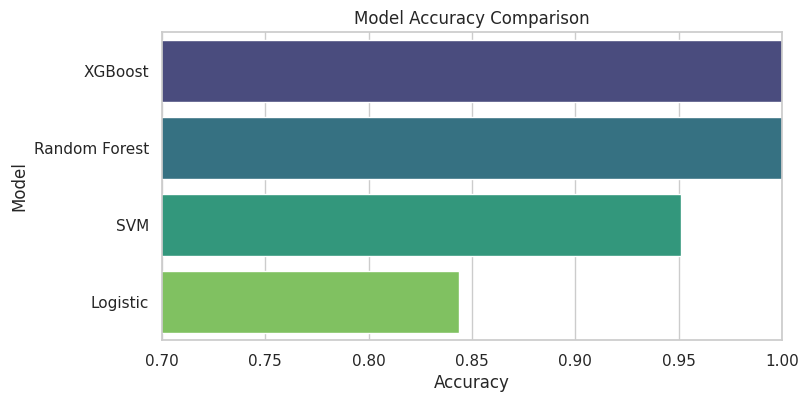

In [41]:
plt.figure(figsize=(8,4))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model",
    palette="viridis"
)

plt.xlim(0.7,1)

plt.title("Model Accuracy Comparison")

plt.show()

In [42]:
params = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid=params,

    cv=5,

    scoring="accuracy",

    n_jobs=-1

)

grid.fit(X_train,y_train)

best_rf = grid.best_estimator_

print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


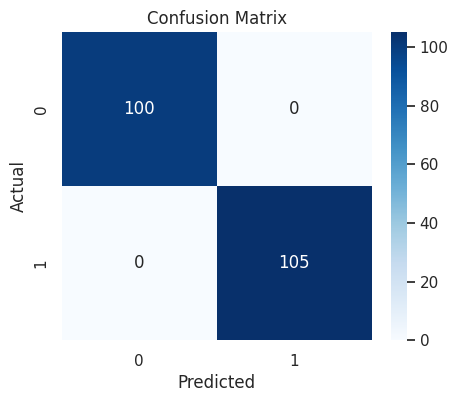

In [43]:
pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test,pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

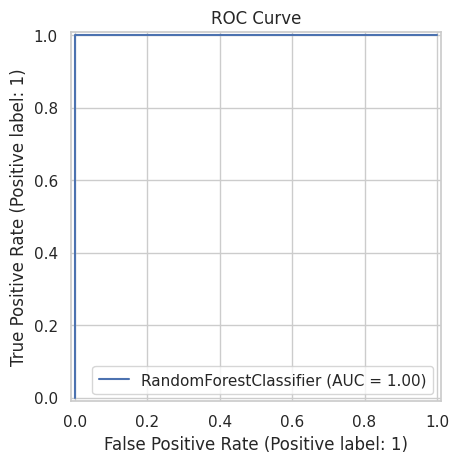

In [44]:
RocCurveDisplay.from_estimator(

    best_rf,

    X_test,

    y_test

)

plt.title("ROC Curve")

plt.show()

In [45]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
2,chest_pain_type,0.144423
7,Max_heart_rate,0.114513
12,thalassemia,0.107506
11,vessels_colored_by_flourosopy,0.104301
9,oldpeak,0.102753
0,age,0.093286
4,cholestoral,0.084241
3,resting_blood_pressure,0.072045
8,exercise_induced_angina,0.071660
10,slope,0.046165


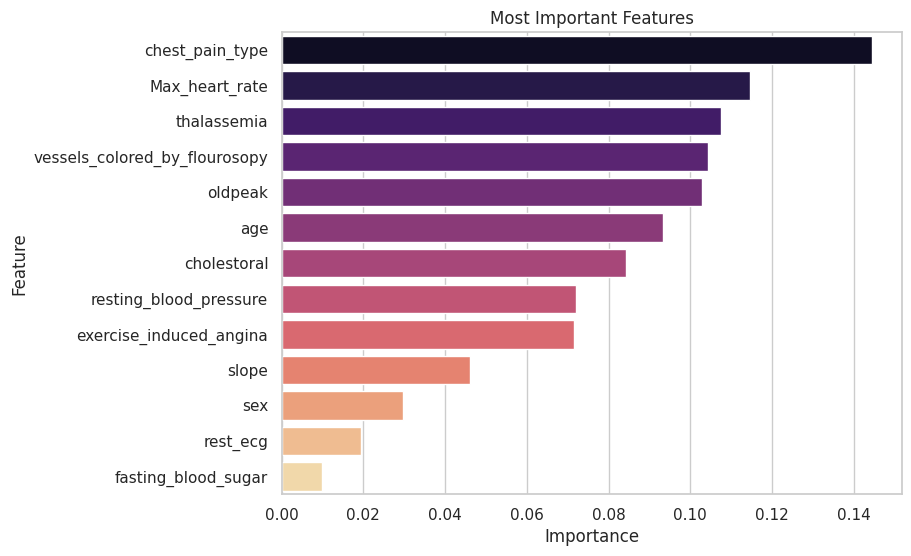

In [46]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    y="Feature",
    x="Importance",
    palette="magma"
)

plt.title("Most Important Features")

plt.show()

In [47]:
joblib.dump(best_rf,"heart_disease_model.pkl")

joblib.dump(scaler,"scaler.pkl")

print("Model Saved")

Model Saved


In [49]:
# New patient data (must match training column names exactly)

new_patient = pd.DataFrame([{
    "age": 58,
    "sex": 1,
    "chest_pain_type": 2,
    "resting_blood_pressure": 140,
    "cholestoral": 240,
    "fasting_blood_sugar": 0,
    "rest_ecg": 1,
    "Max_heart_rate": 150,
    "exercise_induced_angina": 0,
    "oldpeak": 1.2,
    "slope": 2,
    "vessels_colored_by_flourosopy": 0,
    "thalassemia": 2
}])

prediction = best_rf.predict(new_patient)[0]
probability = best_rf.predict_proba(new_patient)[0][1]

print("Prediction:", "Heart Disease" if prediction == 1 else "No Heart Disease")
print(f"Risk Probability: {probability:.2%}")

Prediction: No Heart Disease
Risk Probability: 39.00%


In [52]:
print("---- HEART DISEASE PREDICTION ----\n")

age = int(input("Age: "))

sex = int(input("Sex (Male=1, Female=0): "))

chest_pain_type = int(input("Chest Pain Type (ATA=0, NAP=1, ASY=2, TA=3): "))

resting_blood_pressure = int(input("Resting Blood Pressure: "))

cholestoral = int(input("Cholesterol: "))

fasting_blood_sugar = int(input("Fasting Blood Sugar (Yes=1, No=0): "))

rest_ecg = int(input("Rest ECG (Normal=0, ST=1, LVH=2): "))

Max_heart_rate = int(input("Maximum Heart Rate: "))

exercise_induced_angina = int(input("Exercise Angina (Yes=1, No=0): "))

oldpeak = float(input("Old Peak: "))

slope = int(input("ST Slope (Up=2, Flat=1, Down=0): "))

vessels_colored_by_flourosopy = int(input("Number of Major Vessels (0-3): "))

thalassemia = int(input("Thalassemia (Normal=1, Fixed=2, Reversible=3): "))


# Create dataframe with SAME column names used in training
new_patient = pd.DataFrame([{
    "age": age,
    "sex": sex,
    "chest_pain_type": chest_pain_type,
    "resting_blood_pressure": resting_blood_pressure,
    "cholestoral": cholestoral,
    "fasting_blood_sugar": fasting_blood_sugar,
    "rest_ecg": rest_ecg,
    "Max_heart_rate": Max_heart_rate,
    "exercise_induced_angina": exercise_induced_angina,
    "oldpeak": oldpeak,
    "slope": slope,
    "vessels_colored_by_flourosopy": vessels_colored_by_flourosopy,
    "thalassemia": thalassemia
}])

# Prediction
prediction = best_rf.predict(new_patient)[0]
probability = best_rf.predict_proba(new_patient)[0][1]

print("\n===== RESULT =====")

if prediction == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

print(f"Risk Probability: {probability:.2%}")

---- HEART DISEASE PREDICTION ----

Age: 58
Sex (Male=1, Female=0): 1
Chest Pain Type (ATA=0, NAP=1, ASY=2, TA=3): 2
Resting Blood Pressure: 140
Cholesterol: 240
Fasting Blood Sugar (Yes=1, No=0): 0
Rest ECG (Normal=0, ST=1, LVH=2): 1
Maximum Heart Rate: 150
Exercise Angina (Yes=1, No=0): 0
Old Peak: 1.2
ST Slope (Up=2, Flat=1, Down=0): 2
Number of Major Vessels (0-3): 0
Thalassemia (Normal=1, Fixed=2, Reversible=3): 2

===== RESULT =====
No Heart Disease
Risk Probability: 39.00%
